## Running example from the readme


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

def generate_gp_samples_with_library(n_groups, n_observations_per_group, n_dimensions, time_points, length_scale=1.0):
    """
    Generate multidimensional GP samples using scikit-learn.
    Each dimension has the same underlying process.
    """
    kernel = RBF(length_scale=length_scale)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8)

    gp_sample_constant = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()

    samples = []
    for _ in range(n_groups):
        group_samples = []
        for _ in tqdm(range(n_observations_per_group)):
            # Generate independent samples for each dimension
            gp_samples_per_dim = []
            for _ in range(n_dimensions):
                gp_sample = gp.sample_y(time_points.reshape(-1, 1), random_state=None).flatten()
                gp_samples_per_dim.append(gp_sample)
            # Stack the samples to form a multidimensional sample
            gp_samples_multidim = np.stack(gp_samples_per_dim, axis=-1)
            group_samples.append(gp_samples_multidim)
        samples.append(np.array(group_samples))

    return samples

# Parameters
n_groups = 1
n_observations_per_group = 5000
n_dimensions = 4
n_time_points = 30
time_points = np.linspace(0, 10, n_time_points)
length_scale = 1.5

# Generate GP samples
gp_samples = generate_gp_samples_with_library(
    n_groups=n_groups,
    n_observations_per_group=n_observations_per_group,
    n_dimensions=n_dimensions,
    time_points=time_points,
    length_scale=length_scale
)

if False:
    # Plot example
    for dim in range(n_dimensions):
        for group_idx in range(n_groups):
            plt.figure()
            for observation in gp_samples[group_idx]:
                plt.plot(time_points, observation[:, dim], label=f"Dim {dim + 1}")
            plt.title(f"Group {group_idx + 1} Observations for Dimension {dim + 1}")
            plt.xlabel("Time")
            plt.ylabel("Value")
            plt.legend()
            plt.show()


100%|█████████████████████████████████████| 5000/5000 [00:02<00:00, 2157.33it/s]


In [3]:
n_new_dims = 6
Proj = np.random.uniform(size = (n_dimensions, n_new_dims))#.reshape(1,1,n_dimensions, n_new_dims)
X_ori = gp_samples[0] @ Proj

In [206]:
import torch

def get_errors(gpvae, X, num_samples = 10, p = .2):

    X[X!=X] = 0

    X_corrupted = mcar(X, p)

    #X = X.detach().numpy()
    #X_corrupted = X_corrupted.detach().numpy()

    X_corrupted[X_corrupted!=X_corrupted] = 0
    
    z = gpvae.model.backbone.encoder(torch.tensor(X).float()).mean
    X_recon = gpvae.model.backbone.decoder(z).mean.detach().numpy()
    
    z_corrupted = gpvae.model.backbone.encoder(torch.tensor(X_corrupted).float()).rsample(sample_shape = torch.Size([num_samples]))#
    X_recon_corrupted = gpvae.model.backbone.decoder(z_corrupted).mean.detach().numpy()
    
    error = ((X - X_recon)**2)[X!=0].mean().item()
    
    error_corrupted = np.array([(np.abs(X - x))[X_corrupted!=0].mean().item() for x in X_recon_corrupted]).mean()

    X_recon_corrupted_std = X_recon_corrupted.std(axis=0)

    eps = 1e-1
    
    #print(X_recon_corrupted_std)
    normalized_error = np.array([(np.abs(X - x)) for x in X_recon_corrupted]).mean(axis=0)/(X_recon_corrupted_std + eps)
    #normalized_error = normalized_error.clip(min = 0, max = 10)
    #normalized_error = np.array([((X - x)**2)/X_recon_corrupted_std for x in X_recon_corrupted]).clip(min = 0, max = 10)

    errs = (normalized_error[0]*X_recon_corrupted_std).flatten()
    plt.hist(errs, bins = 50, density = True, alpha = .5, label = 'distribution of errors')
    plt.hist((X_recon_corrupted_std).flatten(), bins = 50, density = True, alpha = .5, label = 'distribution of stds')
    plt.hist((normalized_error[0]).flatten(), bins = 100, density = True, alpha = .5, label = 'distribution of normalized_errors')
    plt.legend()
    plt.xlim([0,30])
    plt.ylim([0,1.2])

    plt.show();

    normalized_error_corrupted_imp = normalized_error[X_corrupted==0].mean()

    normalized_error_corrupted_recon = normalized_error[X_corrupted!=0].mean()

    X[X==0] = np.nan

    xx = np.arange(X.shape[1])
    for i in range(10):
        plt.plot(X_recon_corrupted[i,0], alpha = .3)
    plt.plot(xx, X[0], 'o')
    plt.plot(xx, X_corrupted[0], '+')
    plt.show()

    fig, ax = plt.subplots(2,figsize=(18,8))

    print(X[X_corrupted==0][:100].shape, normalized_error[X_corrupted==0][:100].shape, X_recon_corrupted[:,X_corrupted==0][:,:100].shape)

    ax[0].plot(X_recon_corrupted[:,X_corrupted==0][:,:100].T, c = 'k', alpha = .5)
    ax[0].plot(X[X_corrupted==0][:100], 'o')
    ax[1].semilogy(normalized_error[X_corrupted==0][:100])
    fig.show()

    return [error, error_corrupted, normalized_error_corrupted_imp, normalized_error_corrupted_recon]

In [337]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def get_errors(gpvae, X, num_samples=10, p=0.2, plots = False):
    """
    Computes reconstruction errors and normalized errors for original and corrupted data
    using a Gaussian Process Variational Autoencoder (GPVAE).

    Parameters:
    - gpvae: The GPVAE model instance.
    - X: The input data (numpy array or torch tensor).
    - num_samples: Number of samples to draw for the stochastic encoding.
    - p: Probability of missing data (for corruption).

    Returns:
    - A list containing:
        - error: Mean squared error on the original data.
        - error_corrupted: Mean absolute error on the corrupted data.
        - normalized_error_corrupted_imp: Normalized error for imputed (missing) data.
        - normalized_error_corrupted_recon: Normalized error for observed data.
    """

    # Ensure X is a numpy array and handle NaNs by replacing them with zeros
    X = np.nan_to_num(X, nan=0)

    # Introduce missing completely at random (MCAR) corruption
    X_corrupted = mcar(X, p)  # Assuming mcar function is defined elsewhere
    X_corrupted = np.nan_to_num(X_corrupted, nan=0)

    # Convert data to torch tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    X_corrupted_tensor = torch.tensor(X_corrupted, dtype=torch.float32)

    # Encode and decode the original data
    z = gpvae.model.backbone.encode(X_tensor).mean
    X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()

    # Encode and decode the corrupted data with sampling
    z_corrupted = gpvae.model.backbone.encode(X_corrupted_tensor).rsample(sample_shape=(num_samples,))
    X_recon_corrupted = np.array([gpvae.model.backbone.decode(z).mean.detach().numpy() for z in z_corrupted])

    # Compute mean squared error for the original data (excluding zeros)
    mask_nonzero = X != 0
    error = np.mean((X[mask_nonzero] - X_recon[mask_nonzero]) ** 2)

    # Compute mean absolute error for the corrupted data
    error_list = []
    for x_recon in X_recon_corrupted:
        mask_observed = X_corrupted != 0
        error_sample = np.mean(np.abs(X[mask_observed] - x_recon[mask_observed]))
        error_list.append(error_sample)
    error_corrupted = np.mean(error_list)

    # Compute standard deviation across the reconstructed samples
    X_recon_corrupted_std = np.std(X_recon_corrupted, axis=0)

    # Compute normalized error
    eps = 1e-1  # Small constant to avoid division by zero
    abs_errors = np.mean(np.abs(X_recon_corrupted - X), axis=0)
    normalized_error = abs_errors / (X_recon_corrupted_std + eps)

    # Compute normalized errors for imputed (missing) and observed data
    mask_missing = X_corrupted == 0
    mask_observed = ~mask_missing
    normalized_error_corrupted_imp = normalized_error[mask_missing].mean()
    normalized_error_corrupted_recon = normalized_error[mask_observed].mean()

    error_corrupted_imp = abs_errors[mask_missing].mean()
    error_corrupted_recon = abs_errors[mask_observed].mean()

    if plots:


        plt.plot(X_recon[0])
        plt.plot(X[0],'o')
        plt.plot(X_corrupted[0],'+')
        plt.show()

        # Plot distributions of errors, standard deviations, and normalized errors
        plt.figure(figsize=(12, 6))
        plt.hist((normalized_error * X_recon_corrupted_std).flatten(), bins=50, density=True, alpha=0.5, label='Errors')
        plt.hist(X_recon_corrupted_std.flatten(), bins=50, density=True, alpha=0.5, label='Standard Deviations')
        plt.hist(normalized_error.flatten(), bins=100, density=True, alpha=0.5, label='Normalized Errors')
        plt.legend()
        plt.xlim([0, 30])
        plt.ylim([0, 1.2])
        plt.title('Distribution of Errors and Standard Deviations')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.show()
    
        # Plot reconstructed samples and original data for the first instance
        X_plot = X.copy()
        X_plot[X_plot == 0] = np.nan  # Replace zeros with NaN for plotting
        xx = np.arange(X.shape[1])
    
        plt.figure(figsize=(12, 6))
        for i in range(min(10, num_samples)):
            plt.plot(X_recon_corrupted[i, 0], alpha=0.3)
        plt.plot(xx, X_plot[0], '+', label='Original Data')
        plt.plot(xx, X_corrupted[0], 'o', label='Corrupted Data')
        plt.legend()
        plt.title('Reconstruction of the First Sample')
        plt.xlabel('Feature Index')
        plt.ylabel('Value')
        plt.show()
    
        # Detailed plotting for missing data
        indices_missing = np.where(mask_missing.flatten())[0][:100]  # Get indices of missing data
        fig, ax = plt.subplots(2, figsize=(18, 8))
    
        # Plot reconstructed values for missing data
        ax[0].plot(X_recon_corrupted[:, mask_missing].reshape(num_samples, -1)[:, :100].T, color='k', alpha=0.5)
        ax[0].plot(X[mask_missing].flatten()[:100], 'o', label='Original Missing Data')
        ax[0].set_title('Reconstructed Missing Data')
        ax[0].set_xlabel('Sample Index')
        ax[0].set_ylabel('Value')
        ax[0].legend()
    
        # Plot normalized errors for missing data
        ax[1].semilogy(normalized_error[mask_missing].flatten()[:100])
        ax[1].set_title('Normalized Errors for Missing Data')
        ax[1].set_xlabel('Sample Index')
        ax[1].set_ylabel('Normalized Error')
        plt.tight_layout()
        plt.show()

    return [error, error_corrupted, normalized_error_corrupted_imp, normalized_error_corrupted_recon, error_corrupted_imp, error_corrupted_recon]


In [338]:
err_p030 = get_errors(gpvae, X_normalized, p = .05, plots = False)
print(err_p030)

[0.0008585916597088515, 0.050392965419146674, 0.528157349028012, 0.3210187009769391, 0.11758891438486092, 0.05039296541914671]


In [357]:
list_p_dataset = [0.1, 0.3, 0.5]
list_gamma = [1e-2, 1e0, 1e2]


import torch
import os

#err_p030 = get_errors(gpvae, X)

errors = {}

device = 'cpu'

for p_dataset in list_p_dataset:
    for gamma in list_gamma:
        X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)
        X = mcar(X_normalized, p_dataset)  # randomly hold out 10% observed values as ground truth
        X[X!=X] = 0
        dataset = {'X' : X}

        gpvae = GP_VAE(n_steps = dataset['X'].shape[1], 
                    n_features = dataset['X'].shape[2], 
                    latent_size = 6, 
                    epochs = 50, 
                    batch_size = 8,
                    beta = 1., 
                    K = 20,  
                    encoder_sizes = (128,64), 
                    decoder_sizes = (32,32),
                    optimizer = Adam() #lr = 1e-4
                    )

    
        gpvae.model.backbone.gamma = gamma
        gpvae.model.backbone.alpha = 1e1
        gpvae.model.backbone.p = 0.05
        # Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
        #with torch.autograd.set_detect_anomaly(False):
        gpvae.model.backbone.device = device
        try:
            gpvae.fit(dataset)  # train the model on the dataset
        except:
            print('did,t converge')

        errors[f'p_dataset_{p_dataset}-gamma_{gamma}'] = get_errors(gpvae, X_normalized)
        print(errors)

        os.rename('latent_plots/losses.png', f'latent_plots/losses_p_dataset_{p_dataset}-gamma_{gamma}.png')


2024-11-29 10:58:36 [INFO]: No given device, using default device: cpu
2024-11-29 10:58:36 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2024-11-29 10:58:36 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 12,190
2024-11-29 10:58:36 [ERROR]: ❌ Exception: log(): argument 'input' (position 1) must be Tensor, not float


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=64, out_features=6, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=6, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=6, bias=True)
  )
)
did,t converge
{'p_dataset_0.1-gamma_0.01': [1.0133853454446604, 0.8052235146844857, 5.067930192288333, 5.056837816933406, 0.8078839410932931, 0.8052235146844856]}


FileNotFoundError: [Errno 2] No such file or directory: 'latent_plots/losses.png' -> 'latent_plots/losses_p_dataset_0.1-gamma_0.01.png'

In [347]:
import os


In [ ]:
import pandas as pd
df = pd.DataFrame(errors)

In [ ]:
fig = df.plot(logy=True)
fig.legend(bbox_to_anchor=[1.5, 0.5], loc='center')


In [311]:
from pygrinder import mcar
# Normalize

X_normalized = (X_ori - X_ori.mean(axis=(0,1)).reshape(1,1,-1)) / X_ori.std(axis=(0,1)).reshape(1,1,-1)[:100]
X = mcar(X_normalized.copy(), 0.1)  # randomly hold out 10% observed values as ground truth
X[X!=X] = 0
dataset = {'X' : X}

len_dataset = len(dataset['X'])
cut = int(len_dataset*0.7)
dataset_train, dataset_val = {'X':dataset['X'][:cut]}, {'X':dataset['X'][cut:], 'X_ori':X_normalized[cut:]}

#plt.plot(X_ori[1]);

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_VAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpvae = GP_VAE(n_steps = dataset['X'].shape[1], 
            n_features = dataset['X'].shape[2], 
            latent_size = 6, 
            epochs = 200, 
            batch_size = 8,
            beta = 1., 
            K = 20,  
            encoder_sizes = (128,64), 
            decoder_sizes = (32,32),
            optimizer = Adam() #lr = 1e-4
            )

gpvae.model.backbone.gamma = 1e-2 #* 1e-3 # 0#.1
gpvae.model.backbone.alpha = 1e1 # - 1e-
gpvae.model.backbone.sampling = False
#gpvae.model.backbone.alpha = .5


gpvae.model.backbone.p = 0.05
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
#with torch.autograd.set_detect_anomaly(False):
gpvae.model.backbone.device = 'cpu'
gpvae.fit(dataset_train, dataset_val)  # train the model on the dataset

2024-11-29 10:59:52 [INFO]: No given device, using default device: cpu
2024-11-29 10:59:52 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2024-11-29 10:59:52 [INFO]: GP_VAE initialized with the given hyperparameters, the number of trainable parameters: 12,190


Model dimensions is: 
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=64, out_features=6, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=6, bias=True)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=6, bias=True)
  )
)
3.0226872 3.20389 0.4330309 0.5248733 0.8518402777777778
4.1927285 3.347244 0.31179744 0.36576396 0.8710763888888889
5.4392333 4.239431 0.34555465 0.43686333 0.8456597222222222
5.44198 4.1163974 0.33226556 0.39880437 0.8547222222222223
5.855268 4.513589 0.33892187 0.40790263 0.8644791666666667
5.802891 4.4765153 0.34372324 0.43419617 0.85625


2024-11-29 11:00:13 [INFO]: Epoch 001 - training loss: 229.7326, validation loss: 0.1931


6.2479434 4.36139 0.37499207 0.4498202 0.8516319444444445
5.9982915 4.4507985 0.38539606 0.46004227 0.8607638888888889
4.874664 3.994143 0.33660334 0.42187852 0.8668402777777777
4.624362 3.8159294 0.34612435 0.44180283 0.8571527777777778
4.535432 3.700709 0.3417066 0.41842315 0.8504861111111112
4.700716 3.8670366 0.3504139 0.42487472 0.86125


2024-11-29 11:00:34 [INFO]: Epoch 002 - training loss: 194.4549, validation loss: 0.1879


...

1.8327391 2.7188983 0.1015871 0.20868742 0.8596180555555556
1.8412514 3.1075263 0.10092423 0.2516391 0.8522569444444444
1.9190238 2.68328 0.10758775 0.26058322 0.8473263888888889
1.8137591 2.5294392 0.09999981 0.21615675 0.8538888888888889
1.9233083 2.6555974 0.10670386 0.23863113 0.8535069444444444
1.8786578 2.4952574 0.10507531 0.23576869 0.8610763888888889
1.8234726 2.314666 0.09693057 0.20052741 0.8625347222222223


2024-11-29 12:05:03 [INFO]: Epoch 170 - training loss: 173.3149, validation loss: 0.0139


1.7219834 2.4389107 0.09753373 0.23672287 0.8507638888888889
1.9295044 2.6054518 0.09865699 0.22780214 0.8597916666666666
1.7829092 2.6657245 0.10063984 0.22472674 0.8575347222222223
1.8249384 2.8830202 0.098765284 0.24103005 0.8571180555555555
1.9320868 2.897592 0.10393501 0.23917033 0.8538888888888889
1.8312182 2.7832205 0.096008904 0.21792561 0.8596875


2024-11-29 12:05:22 [INFO]: Epoch 171 - training loss: 173.2398, validation loss: 0.0142


1.756556 2.8589418 0.10210752 0.2563907 0.846875
1.8570868 2.4348795 0.100998 0.22522573 0.8573958333333334


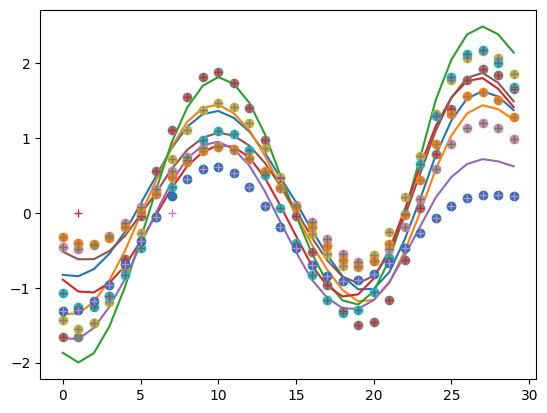

[0.07826495709977789,
 0.2204802946523766,
 3.9511829644270278,
 1.4514753918898384,
 0.6037537627156535,
 0.22048029465237667]

In [326]:
get_errors(gpvae, X_ori, num_samples = 20, p = .01)

In [262]:
X_ori.shape, z.shape

((5000, 30, 6), torch.Size([5000, 30, 6]))

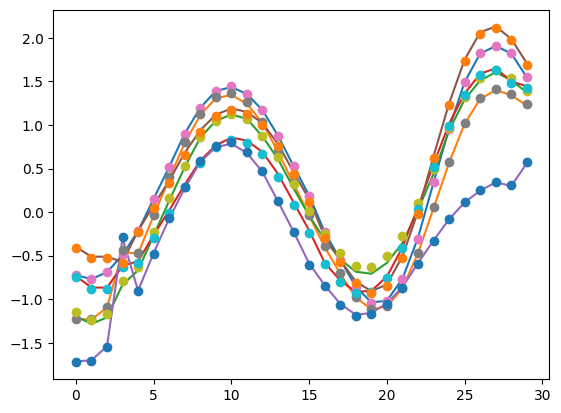

In [318]:
qz_x = gpvae.model.backbone.encode(torch.tensor(X_recon).float())
z = qz_x.mean
X_recon_2 = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon_2[0])
plt.plot(X_recon[0],'o')
plt.show();

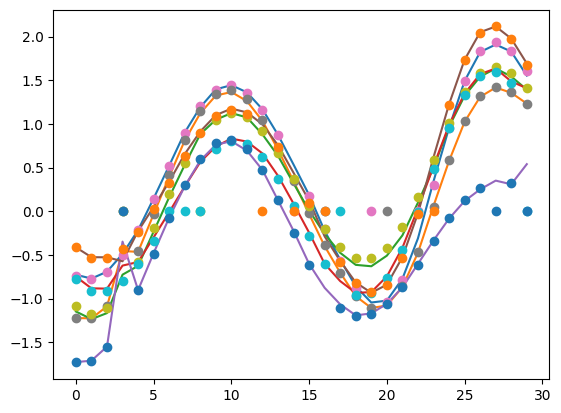

In [325]:
qz_x = gpvae.model.backbone.encode(torch.tensor(X).float())
z = qz_x.mean
X_recon = gpvae.model.backbone.decode(z).mean.detach().numpy()
plt.plot(X_recon[0])
plt.plot(X[0],'o')
plt.show();

In [247]:
#gpvae.model.backbone.sampling = True
#gpvae.model.backbone.alpha = 1e1

gpvae.fit(dataset)  # train the model on the dataset

#gpvae.model.backbone.alpha = 1e2

3.8698883 1.0461842 0.09590341 0.40753928 0.9384722222222223
1.2911105 0.9160542 0.04721734 0.35130376 0.9465277777777777
1.6707888 0.93289673 0.058197632 0.38335517 0.939375
1.6775497 0.927616 0.0510141 0.3513282 0.9414583333333333
1.3271815 0.89719576 0.05478649 0.35872275 0.9415972222222222
2.546657 0.9794392 0.064299315 0.36524576 0.9440972222222223


2024-11-28 18:01:52 [INFO]: Epoch 001 - training loss: 99.2697


1.4064809 0.9146605 0.04724319 0.34790567 0.9446180555555556
1.3347161 0.92686623 0.043004528 0.3431084 0.9445833333333333
2.875531 0.95127267 0.10087999 0.4534637 0.9350347222222222
1.7420758 0.9378362 0.06542953 0.39201498 0.9349305555555556
2.6214297 1.0748181 0.06007058 0.37339643 0.9425347222222222
2.2656395 0.94650614 0.06717788 0.41934973 0.9412847222222223
1.1850585 0.92198133 0.06320025 0.43702945 0.9370486111111112


2024-11-28 18:02:51 [INFO]: Epoch 002 - training loss: 92.9380


3.22961 0.9288746 0.10502943 0.47404 0.9377777777777778
1.2622762 0.9288226 0.048630163 0.39406234 0.9381597222222222
3.3892653 1.2103913 0.066366926 0.39470598 0.9444097222222222
1.8539416 0.9931948 0.055071644 0.37640208 0.9402430555555555
2.3630865 1.0820509 0.06024226 0.37835574 0.9403472222222222
1.5113515 0.96058154 0.050830044 0.40677473 0.9401736111111111


2024-11-28 18:03:46 [INFO]: Epoch 003 - training loss: 75.9169
2024-11-28 18:03:46 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2024-11-28 18:03:46 [INFO]: Finished training. The best model is from epoch#3.


2024-11-26 19:54:37 [INFO]: Epoch 001 - training loss: 11.1983


mean of mask of imputed coords : tensor(0.0854)


/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py:540: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 8))
/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py:575: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))
/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py:528: RuntimeWarning: More than 

mean of mask of imputed coords : tensor(0.0858)


2024-11-26 19:55:00 [INFO]: Epoch 003 - training loss: 11.1939
2024-11-26 19:55:12 [INFO]: Epoch 004 - training loss: 11.1587


...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

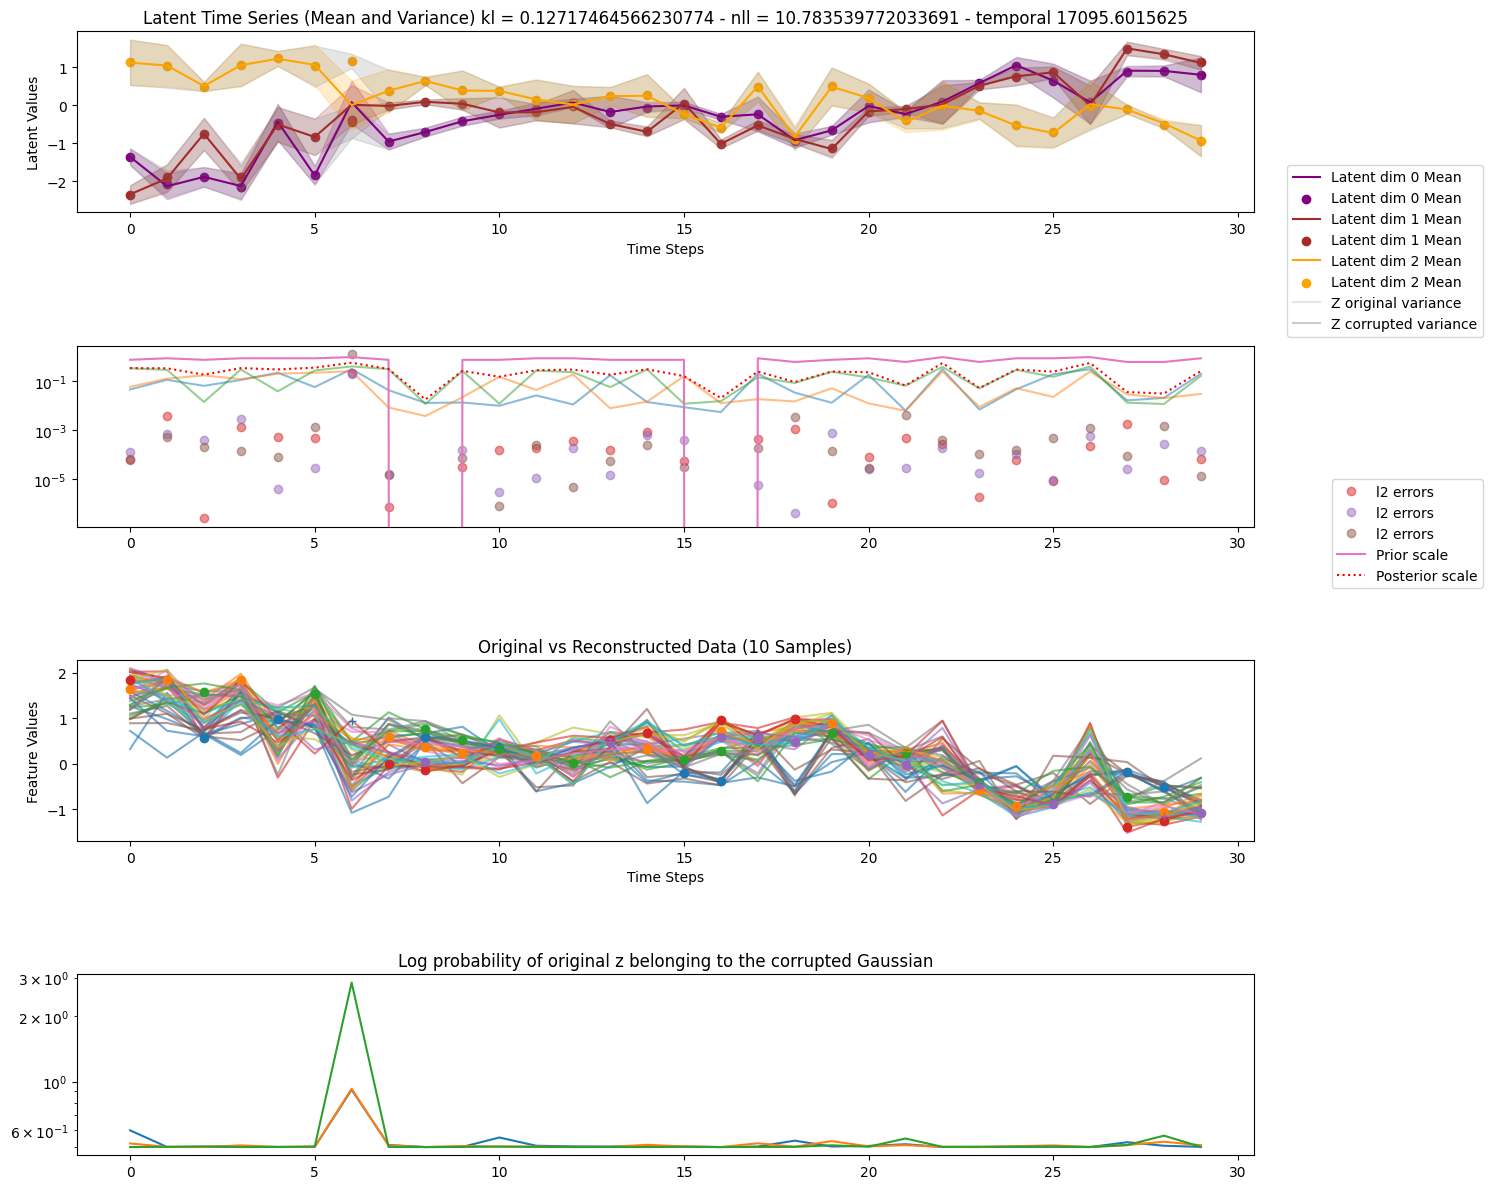

In [ ]:
gpvae.model.backbone.alpha = 1e0 # - 1e-
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
#gpvae.model.backbone.alpha = 1 - 1e-1 #1 - 1e-
#gpvae.model.backbone.gamma = 1e-7 # 0#.1
#gpvae.model.backbone.alpha = 1e-4
for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = True
gpvae.model.backbone.p = .1
gpvae.fit(dataset)  # train the model on the dataset

mean of mask of imputed coords : tensor(0.2904)


2024-11-25 15:54:42 [INFO]: Epoch 001 - training loss: 11.4479
/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py:522: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  
/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py:557: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  
/Users/louis/Documents/Phd/Code_pour_manuscript/PyPOTS/pypots/nn/modules/gp_ae/backbone.py:510: RuntimeWarning: M

mean of mask of imputed coords : tensor(0.3083)


2024-11-25 15:55:02 [INFO]: Epoch 003 - training loss: 11.3893


mean of mask of imputed coords : tensor(0.2942)


...

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

Error in callback <function flush_figures at 0x29dcf05e0> (for post_execute):


KeyboardInterrupt: 

In [ ]:
gpvae.model.backbone.train_decoder = False
for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = False
gpvae.alpha = 1 - 1e-3
gpvae.fit(dataset)  # train the model on the dataset

[autoreload of pypots.nn.modules.gp_ae.backbone failed: Traceback (most recent call last):
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 273, in check
    superreload(m, reload, self.old_objects)
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 496, in superreload
    update_generic(old_obj, new_obj)
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 393, in update_generic
    update(a, b)
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 361, in update_class
    update_instances(old, new)
  File "/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 315, in update_instances
    refs = gc.get_referrers(old)
KeyboardInterrupt
]
2024-11-25 10:58:20 [WARNING]: ‼️ Training got interrupted

TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

In [ ]:
gpvae.model.backbone.alpha = 1 - 1e-1 #.005
gpvae.model.backbone.p = 0.3
gpvae.beta = 100
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
## define tests to evaluate convergence of AE

## Assess reconstruction error
import torch

def get_errors(gpvae, X):

    X_corrupted = mcar(X, 0.3)
    X_corrupted[X_corrupted!=X_corrupted] = 0
    
    z = gpvae.model.backbone.encoder(torch.tensor(X).float()).mean
    X_recon = gpvae.model.backbone.decoder(z).mean
    
    z_corrupted = gpvae.model.backbone.encoder(torch.tensor(X_corrupted).float()).rsample()#sample_shape = torch.Size([10])
    X_recon_corrupted = gpvae.model.backbone.decoder(z_corrupted).mean
    
    error = (torch.tensor(X).float() - X_recon).pow(2)[X!=0].mean().item()
    
    error_corrupted = (torch.tensor(X).float() - X_recon_corrupted).pow(2)[X_corrupted!=0].mean().item()
    
    error_imputation_corrupted = (torch.tensor(X).float() - X_recon_corrupted).pow(2)[X_corrupted==0].mean().item()
    
    print(error, error_corrupted, error_imputation_corrupted)

    return [error, error_corrupted, error_imputation_corrupted]

err_p030 = get_errors(gpvae, X)


In [ ]:
errs = {}

errs[f'p_dataset_{p_dataset}_p_model_{p_model}_gamma_{gamma}'] = get_errors(gpvae, X)

In [ ]:
gpvae.model.backbone.p = 0.1

#gpvae.model.backbone.load_state_dict(torch.load('model_weights2.pth'))
gpvae.epochs = 100
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
# Assume 'model' is your neural network instance
torch.save(gpvae.model.backbone.state_dict(), 'model_weights_p030.pth')

#gpvae_backup = gpvae

In [ ]:
import torch
#gpvae.model.backbone.load_state_dict(torch.load('model_weights_p005.pth'))

gpvae.model.backbone.train_decoder = False
for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = True
gpvae.epochs = 100
    
gpvae.model.backbone.p = 0.1
gpvae.model.backbone.gamma = 1e-3
gpvae.model.backbone.sampling = True


# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset

mean of mask of imputed coords : tensor(0.1596)


2024-11-26 21:24:45 [INFO]: Epoch 001 - training loss: 33.0630
2024-11-26 21:25:35 [INFO]: Epoch 002 - training loss: 33.2797


mean of mask of imputed coords : tensor(0.1513)


2024-11-26 21:26:18 [INFO]: Epoch 003 - training loss: 32.9374


mean of mask of imputed coords : tensor(0.1658)


...

2024-11-26 21:37:13 [INFO]: Epoch 019 - training loss: 32.3770


mean of mask of imputed coords : tensor(0.1858)


2024-11-26 21:37:54 [INFO]: Epoch 020 - training loss: 32.5890
2024-11-26 21:38:35 [INFO]: Epoch 021 - training loss: 32.4959


mean of mask of imputed coords : tensor(0.1729)


2024-11-26 21:39:17 [INFO]: Epoch 022 - training loss: 32.4466
2024-11-26 21:39:41 [WARNING]: ‼️ Training got interrupted by the user. Exist now ...
2024-11-26 21:39:41 [INFO]: Finished training. The best model is from epoch#13.


In [ ]:
# Assume 'model' is your neural network instance
torch.save(gpvae.model.backbone.state_dict(), 'model_weights2.pth')

#gpvae_backup = gpvae

In [ ]:
gpvae.model.backbone.load_state_dict(torch.load('model_weights2.pth'))


for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = False
    
gpvae.model.backbone.p = 0.3
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
#gpvae.model.backbone.load_state_dict(torch.load('model_weights2.pth'))


for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = False
    
gpvae.model.backbone.p = 0.3
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset

## RUN THIS

In [ ]:
gpvae.model.backbone.p = 0.1

gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
## Assess reconstruction error
import torch

z = gpvae.model.backbone.encoder(torch.tensor(X).float()).mean
X_recon = gpvae.model.backbone.decoder(z).mean

error = (torch.tensor(X).float() - X_recon).pow(2)[X!=0].mean()

print(error)

tensor(0.0007, grad_fn=<MeanBackward0>)


In [ ]:
for param in gpvae.model.backbone.decoder.parameters():
    param.requires_grad = False
    
gpvae.model.backbone.p = 0.1
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
gpvae.model.backbone.p = .3
gpvae.model.backbone.sampling = True
gpvae.fit(dataset)  # train the model on the dataset

In [ ]:
import gpytorch
import torch
with gpytorch.settings.cholesky_jitter(1e-4):
    with torch.autograd.set_detect_anomaly(True):
        gpvae.fit_kernel(dataset)  # train the model on the dataset


fitting kernel


/Users/louis/miniforge3/envs/pypots3/lib/python3.8/site-packages/gpytorch/models/exact_gp.py:284: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
gpvae.gp.gp_models[0].covar_module.outputscale


In [ ]:
help(gpvae.gp.gp_models[0].covar_module)


In [ ]:
import torch
x = torch.ones((8,48))
gpvae.gp.gp_models[0](x)

In [ ]:
gpvae.gp._fit_kernel

In [ ]:
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/gpvae_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/gpvae_physionet2012.pypots")  # reload the serialized model file for following imputation or training

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import GPVAE
from pypots.utils.metrics import calc_mae
gpvae = GPVAE(n_steps=48, n_features=37, latent_size = 12, epochs=10)
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/gpvae_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/gpvae_physionet2012.pypots")  # reload the serialized model file for following imputation or training

In [ ]:

# Model training. This is PyPOTS showtime.
from pypots.imputation import SAITS
from pypots.utils.metrics import calc_mae
gpvae = SAITS(n_steps=48, n_features=37, n_layers=2, d_model=256, n_heads=4, d_k=64, d_v=64, d_ffn=128, dropout=0.1, epochs=10)
# Here I use the whole dataset as the training set because ground truth is not visible to the model, you can also split it into train/val/test sets
gpvae.fit(dataset)  # train the model on the dataset
imputation = gpvae.impute(dataset)  # impute the originally-missing values and artificially-missing values
indicating_mask = np.isnan(X) ^ np.isnan(X_ori)  # indicating mask for imputation error calculation
mae = calc_mae(imputation, np.nan_to_num(X_ori), indicating_mask)  # calculate mean absolute error on the ground truth (artificially-missing values)
gpvae.save("save_it_here/saits_physionet2012.pypots")  # save the model for future use
gpvae.load("save_it_here/saits_physionet2012.pypots")  # reload the serialized model file for following imputation or training